# K-Means Clustering

## What Is K-Means?

K-Means is an **unsupervised learning** algorithm that partitions data into $K$ groups (clusters) based on similarity. Unlike supervised learning, there are no labels — the algorithm discovers structure in the data purely from the features $\mathbf{X}$.

The goal is to find $K$ clusters such that points within the same cluster are as similar as possible, and points in different clusters are as different as possible.

## Mathematical Formulation

Given a dataset $\mathbf{X} = \{\mathbf{x}_1, \mathbf{x}_2, \ldots, \mathbf{x}_n\}$, we want to partition the $n$ points into $K$ clusters, each represented by a **centroid**:

$$\mu_1,\ \mu_2,\ \ldots,\ \mu_K$$

### Objective Function

K-Means minimizes the **Within-Cluster Sum of Squares (WCSS)**, also called inertia:

$$J = \sum_{i=1}^{n} \sum_{k=1}^{K} r_{ik} \|\mathbf{x}_i - \mu_k\|^2$$

Where:

- $r_{ik} = 1$ if point $\mathbf{x}_i$ belongs to cluster $k$, and $0$ otherwise
- $\|\mathbf{x}_i - \mu_k\|^2$ is the squared Euclidean distance from point $i$ to centroid $k$

Minimizing $J$ means pulling each point as close as possible to its assigned centroid.

## The Algorithm

K-Means alternates between two steps until convergence:

**Step 1 — Initialize:** Place $K$ centroids randomly in the feature space.

**Step 2 — Assignment:** Assign each point to the nearest centroid:

$$\text{cluster}(\mathbf{x}_i) = \underset{k}{\arg\min}\ \|\mathbf{x}_i - \mu_k\|$$

**Step 3 — Update:** Recompute each centroid as the mean of all points assigned to it:

$$\mu_k = \frac{1}{N_k} \sum_{\mathbf{x}_i \in \text{cluster } k} \mathbf{x}_i$$

Where $N_k$ is the number of points in cluster $k$.

**Step 4 — Repeat** Steps 2 and 3 until the centroids stop moving or assignments no longer change.

### Convergence

The algorithm is guaranteed to converge because $J$ decreases or stays the same at every step — the assignment step minimizes $J$ over $r_{ik}$, and the update step minimizes $J$ over $\mu_k$. However, it may converge to a **local minimum** rather than the global one. This is why K-Means is typically run multiple times with different random initializations, and the best result (lowest $J$) is kept.

## Evaluation Metrics

Since there are no labels, standard classification metrics do not apply. Clustering quality is measured using **internal metrics** that assess structure within the data itself.

### Inertia (WCSS) (Within-Cluster Sum of Squares)

The value of the objective function at convergence:

$$\text{Inertia} = \sum_{i=1}^{n} \|\mathbf{x}_i - \mu_{k(i)}\|^2$$

Lower inertia means tighter, more compact clusters. However, inertia always decreases as $K$ increases — even if the extra clusters are meaningless — so it cannot be used alone to select $K$.

### Silhouette Score

The silhouette score measures how well each point fits within its assigned cluster compared to the next nearest cluster:

$$s = \frac{b - a}{\max(a,\ b)}$$

Where:

- $a$ = mean distance from the point to all other points **in the same cluster** (intra-cluster distance)
- $b$ = mean distance from the point to all points **in the nearest other cluster** (inter-cluster distance)

| Score | Interpretation |
|---|---|
| $s \approx 1$ | Point is well inside its cluster, far from others |
| $s \approx 0$ | Point is near the boundary between two clusters |
| $s \approx -1$ | Point is likely assigned to the wrong cluster |

The overall silhouette score is the mean $s$ across all points. Higher is better. Unlike inertia, silhouette score penalizes both poor cohesion and poor separation simultaneously, making it a more reliable metric for selecting $K$.

## Finding the Optimal K

The number of clusters $K$ is a hyperparameter — it must be chosen before training. Three standard approaches:

### Method 1: The Elbow Method

Plot inertia against $K$ for a range of values. As $K$ increases, inertia always decreases, but the rate of decrease slows. The **elbow** — the point where the curve bends and further increases in $K$ give diminishing returns — is a good candidate for the optimal $K$.

The elbow is often subjective. If the curve is smooth with no clear bend, the silhouette method is more reliable.

### Method 2: Silhouette Score

Compute the mean silhouette score for each value of $K$ and select the $K$ that maximizes it. This is more principled than the elbow method because it directly measures cluster quality rather than just compactness.

### Method 3: Gap Statistic (Advanced)

Compares the observed inertia against the inertia expected under a **null reference distribution** (randomly distributed data). The optimal $K$ is where the gap between the two is largest — meaning the real clustering structure is most distinct from random noise. This method is statistically rigorous but computationally expensive.

## Assumptions and Limitations

K-Means works best when the following assumptions hold:

- Clusters are **roughly spherical** — K-Means uses Euclidean distance, so it naturally finds round clusters
- Clusters have **similar variance** — it struggles when one cluster is much more spread out than another
- Clusters have **similar size** — very imbalanced cluster sizes can cause centroids to drift toward the larger group

K-Means will always produce $K$ clusters even if the data has no meaningful grouping. It is important to validate results with silhouette score or domain knowledge rather than accepting the output blindly.

For non-spherical or irregularly shaped clusters, **DBSCAN** or **Gaussian Mixture Models** are more appropriate alternatives.

## Train-Test Split in Clustering

Since K-Means has no target variable $y$, a train-test split is **not required** in the standard sense. The algorithm is simply fit to the full dataset.

However, a split becomes relevant in two scenarios:

- **Feature engineering** — if cluster labels are used as input features for a downstream supervised model, the clustering must be fit only on training data to avoid data leakage
- **Stability evaluation** — fitting on one subset and evaluating silhouette scores on a held-out subset can check whether the discovered clusters generalize or are artifacts of the specific sample

Outside of these cases, the full dataset is typically used for clustering.

### Intuition Summary

**K-Means is:**

- Variance minimization

- Distance-based grouping

- Iterative optimization

**It works beautifully when:**

- Clusters are circular

- Balanced in size

- Fails when:

- Clusters are non-linear (moons, spirals)

- Different densities

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

X, _ = make_blobs(n_samples=500, # type: ignore
                  centers=4,
                  cluster_std=1.2,
                  random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

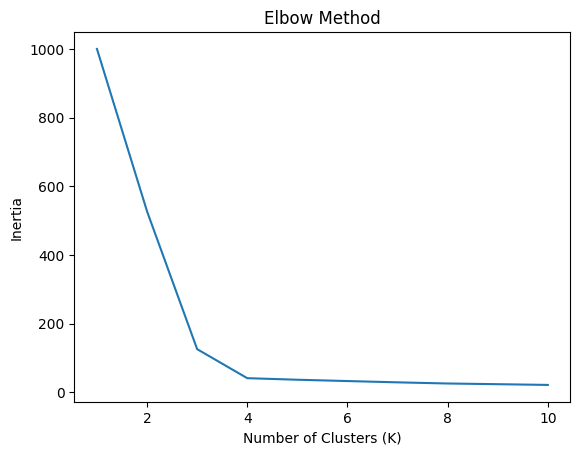

In [4]:
# Elbow method

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

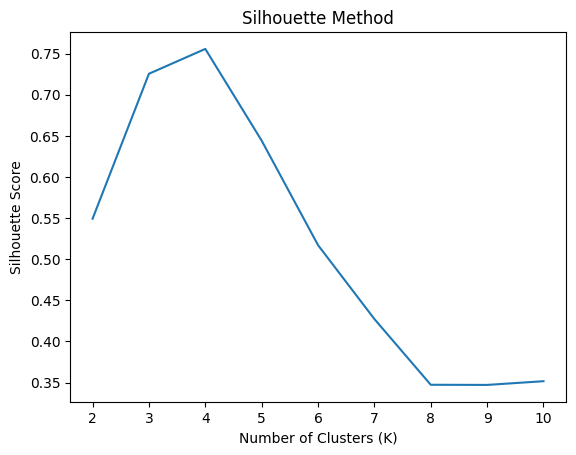

In [5]:
# Silhouette Method
sil_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

plt.plot(range(2, 11), sil_scores)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method")
plt.show()

In [18]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

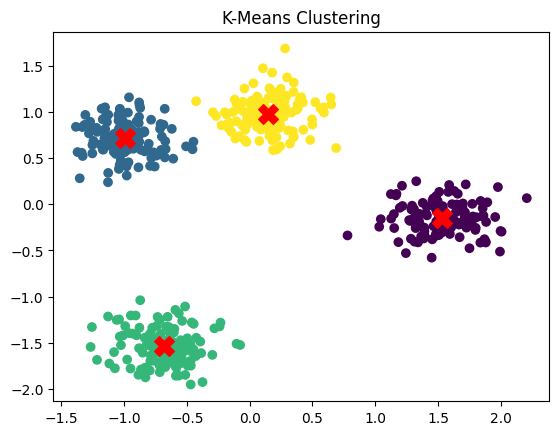

In [19]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1],
            c=labels, cmap='viridis')

plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            color='red', marker='X', s=200)

plt.title("K-Means Clustering")
plt.show()